In [35]:
# ============================================================
# Cell 1: Import required libraries
# ============================================================
# This cell imports:
# - NumPy for array operations
# - TensorFlow / Keras for the neural networks
# - Matplotlib for plotting images
# - skimage metrics for PSNR and SSIM evaluation
# - scikit-learn metrics for classifier evaluation

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Optional: set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [36]:
# ============================================================
# Cell 2: Load the MNIST dataset
# ============================================================
# MNIST contains 28x28 grayscale handwritten digit images.
# For denoising, we use the images.
# For classification comparison, we also keep the digit labels.

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Raw x_train shape:", x_train.shape)
print("Raw x_test shape :", x_test.shape)
print("Raw y_train shape:", y_train.shape)
print("Raw y_test shape :", y_test.shape)

Raw x_train shape: (60000, 28, 28)
Raw x_test shape : (10000, 28, 28)
Raw y_train shape: (60000,)
Raw y_test shape : (10000,)


In [37]:
# ============================================================
# Cell 3: Normalize pixel values and reshape for CNN input
# ============================================================
# Pixel values originally range from 0 to 255.
# We scale them to [0, 1] for stable neural network training.
#
# CNNs in Keras expect image tensors with shape:
# (batch, height, width, channels)
#
# Since MNIST is grayscale, the channel count is 1.
# We also keep the label vectors for later classifier training.

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)   # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)    # (10000, 28, 28, 1)

print("Processed x_train shape:", x_train.shape)
print("Processed x_test shape :", x_test.shape)
print("x_train min/max:", x_train.min(), x_train.max())
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Processed x_train shape: (60000, 28, 28, 1)
Processed x_test shape : (10000, 28, 28, 1)
x_train min/max: 0.0 1.0
y_train shape: (60000,)
y_test shape : (10000,)


# Cell B — Dataset Preparation: Creating Supervised Denoising and Classification Data

The MNIST dataset provides clean images of handwritten digits together with digit labels.

For the denoising task, we artificially create noisy measurements:

$$
y = x + n
$$

where

- $x$ = clean MNIST digit  
- $n$ = Gaussian noise  

This produces denoising training pairs:

| Input | Target |
|------|------|
| noisy digit $y$ | clean digit $x$ |

The neural network learns the mapping

$$
N(y) \rightarrow x
$$

We also retain the digit labels so that, after denoising, we can measure how well digit identity is preserved by comparing classification performance on:

- clean images
- noisy images
- denoised images

# Cell L — Classification-Based Evaluation of the Denoiser

Pixel-wise metrics such as PSNR and SSIM measure reconstruction quality, but they do not directly measure whether the denoised image preserves the information needed for recognition.

To evaluate that, we train a digit classifier on clean MNIST and test it on three versions of the test set:

1. original clean MNIST
2. noisy MNIST
3. denoised MNIST

This lets us compare how much class information is lost due to noise and how much is recovered by the denoiser.

In [38]:
# ============================================================
# Cell 4: Add Gaussian noise to create noisy MNIST digits
# ============================================================
# This simulates corrupted input images.
# The network will learn to map:
#
#   noisy image  ->  clean image
#
# noise_factor controls how strong the noise is.
# Start with 0.5 to match the online simpler example.

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

# Clip values so they remain valid grayscale intensities
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy, 0.0, 1.0)

print("Noisy x_train shape:", x_train_noisy.shape)
print("Noisy x_test shape :", x_test_noisy.shape)
print("Noisy train min/max:", x_train_noisy.min(), x_train_noisy.max())

Noisy x_train shape: (60000, 28, 28, 1)
Noisy x_test shape : (10000, 28, 28, 1)
Noisy train min/max: 0.0 1.0


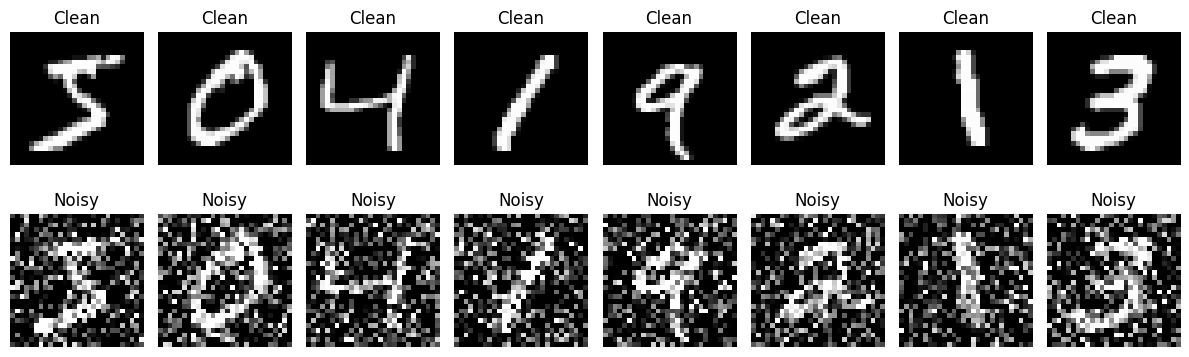

In [39]:
# ============================================================
# Cell 5: Display sample clean and noisy digits
# ============================================================
# This helps verify that the noisy images were generated correctly.

n = 8
plt.figure(figsize=(12, 4))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Clean")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.axis("off")
    plt.title("Noisy")

plt.tight_layout()
plt.show()

# Cell D — Encoder Structure

The first half of the autoencoder is called the **encoder**.

Its purpose is to convert the input image into a **compressed feature representation**.

Operations in the encoder typically include:

- convolution layers (feature extraction)
- pooling layers (spatial compression)

Conceptually:

input image  
→ edge detectors  
→ shape detectors  
→ compressed feature maps

The encoder extracts the **important structures of the image while suppressing noise**.

# Cell E — Bottleneck Representation

The **bottleneck** is the most compressed representation of the image inside the network.

It contains the minimal set of features needed to reconstruct the image.

Because the bottleneck has fewer parameters than the original image, the network is forced to learn:

- digit structure
- spatial correlations
- meaningful patterns

Random noise cannot be efficiently represented in this compressed form, so it is naturally suppressed.

This is one reason autoencoders are effective for **denoising tasks**.

# Cell F — Decoder Structure

The second half of the network is the **decoder**.

The decoder reconstructs the image from the compressed feature representation.

Typical decoder operations include:

- convolution layers
- upsampling layers

Conceptually:

compressed features  
→ reconstruction filters  
→ denoised image

The decoder transforms the learned feature representation back into an image that closely matches the ground truth digit.

In [40]:
# ============================================================
# Cell 6: Define the simple CNN autoencoder
# ============================================================
# This architecture matches the online simpler example closely.
#
# Encoder:
# - Conv2D(32)
# - MaxPooling2D
# - Conv2D(32)
# - MaxPooling2D
#
# Decoder:
# - Conv2D(32)
# - UpSampling2D
# - Conv2D(32)
# - UpSampling2D
# - Conv2D(1) output
#
# The encoder compresses the image into a smaller latent feature map.
# The decoder reconstructs a clean image from that compressed representation.

def build_autoencoder():
    input_img = Input(shape=(28, 28, 1))

    # ---------------- Encoder ----------------
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2), padding="same")(x)

    # ---------------- Decoder ----------------
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = Model(input_img, decoded)

    # Match the online simpler example
    autoencoder.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

# Cell G — Loss Function

The network is trained by minimizing the difference between:

- the reconstructed image
- the clean ground truth image

A common loss function is **Mean Squared Error (MSE)**:

$$
L = \frac{1}{N}\sum (x - \hat{x})^2
$$

where

- $x$ = clean image  
- $\hat{x}$ = reconstructed image  

The optimizer adjusts the convolutional kernels to minimize this error across the entire training dataset.

In [41]:
# ============================================================
# Cell 7: Train the denoising autoencoder
# ============================================================
# Input  = noisy image
# Target = clean image
#
# The model learns to remove the noise and reconstruct the clean digit.

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - loss: 0.2549 - val_loss: 0.1196
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.1186 - val_loss: 0.1108
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.1111 - val_loss: 0.1065
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - loss: 0.1072 - val_loss: 0.1039
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.1047 - val_loss: 0.1023
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.1029 - val_loss: 0.1008
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - loss: 0.1017 - val_loss: 0.1001
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.1007 - val_loss: 0.0993
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.0999 - val_loss: 0.0986
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - loss: 0.0992 - val_loss: 0.0980


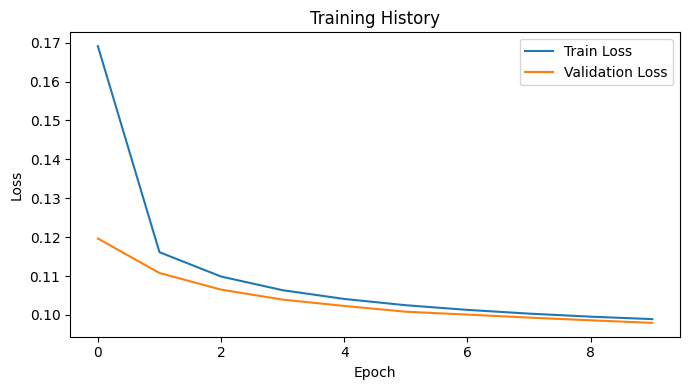

In [42]:
# ============================================================
# Cell 8: Plot training and validation loss
# ============================================================
# This helps verify that the model is learning during training.

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# Cell 9: Generate denoised test images
# ============================================================
# The trained model predicts cleaned versions of the noisy test images.

denoised_images = autoencoder.predict(x_test_noisy)

print("Denoised output shape:", denoised_images.shape)
print("Output min:", denoised_images.min())
print("Output max:", denoised_images.max())
print("Output mean:", denoised_images.mean())

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Denoised output shape: (10000, 28, 28, 1)
Output min: 3.2164318e-10
Output max: 0.99896866
Output mean: 0.12986688


In [44]:
# ============================================================
# Cell 10: Evaluate the model on the noisy test set
# ============================================================
# This computes the final reconstruction loss on the test data.

test_loss = autoencoder.evaluate(x_test_noisy, x_test)
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0973
Final Test Loss: 0.0980


In [45]:
# ============================================================
# Cell 11: Compute PSNR and SSIM quality metrics
# ============================================================
# PSNR measures pixel-level reconstruction quality.
# SSIM measures structural similarity between clean and denoised images.

psnr_values = [
    psnr(x_test[i].squeeze(), denoised_images[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
]

ssim_values = [
    ssim(x_test[i].squeeze(), denoised_images[i].squeeze(), data_range=1.0)
    for i in range(len(x_test))
]

print(f"Average PSNR: {np.mean(psnr_values):.2f} dB")
print(f"Average SSIM: {np.mean(ssim_values):.4f}")

Average PSNR: 19.69 dB
Average SSIM: 0.8616


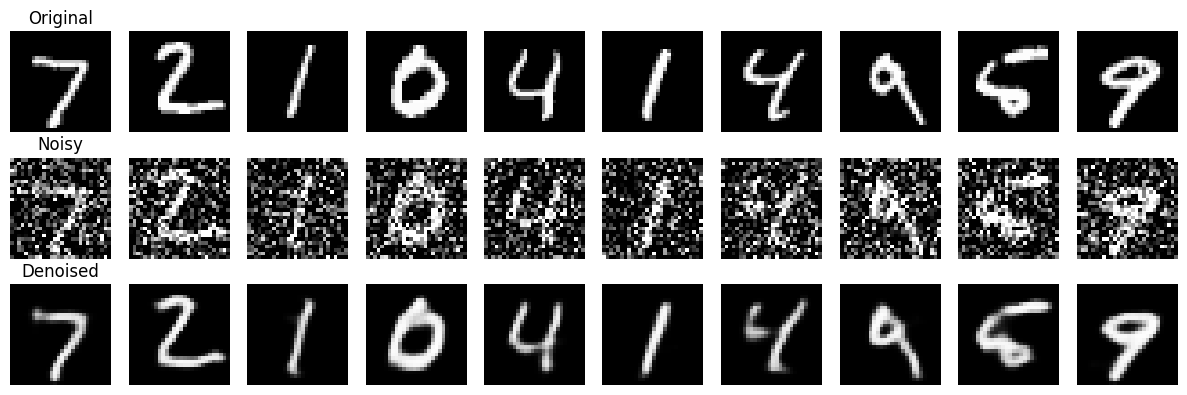

In [46]:
# ============================================================
# Cell 12: Plot original, noisy, and denoised images
# ============================================================
# This visualizes how well the autoencoder reconstructs the digits.

def plot_images(original, noisy, denoised, n=10):
    plt.figure(figsize=(12, 4))

    for i in range(n):
        # Original image
        plt.subplot(3, n, i + 1)
        plt.imshow(original[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        # Noisy image
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Noisy")

        # Denoised image
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(denoised[i].squeeze(), cmap="gray", vmin=0, vmax=1)
        plt.axis("off")
        if i == 0:
            plt.title("Denoised")

    plt.tight_layout()
    plt.show()

plot_images(x_test, x_test_noisy, denoised_images, n=10)

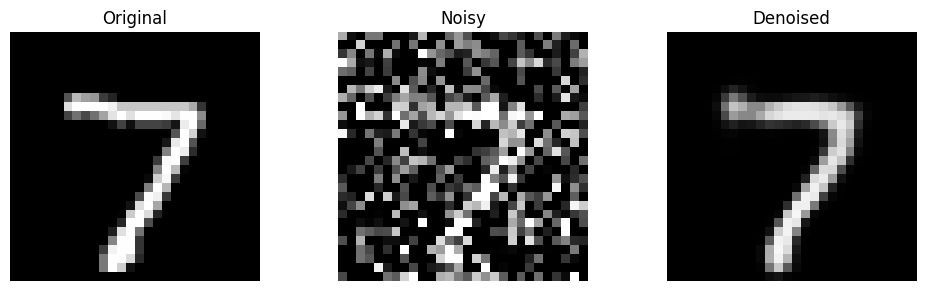

In [47]:
# ============================================================
# Cell 13: Optional single-image inspection
# ============================================================
# Useful for closely comparing one original/noisy/denoised example.

idx = 0

plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.imshow(x_test[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_test_noisy[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Denoised")
plt.axis("off")

plt.tight_layout()
plt.show()

# Cell H — Interpretation in Computational Imaging

This neural network can be interpreted as learning the **inverse operator of an imaging system**.

In many imaging systems, measurements follow:

$$
y = A x + n
$$

where $A$ represents optical effects such as

- blur
- diffraction
- defocus
- scattering

The neural network approximates the inverse mapping:

$$
N(y) \approx A^{-1}(y)
$$

Thus the CNN acts as a **learned reconstruction algorithm**.

# Cell I — Relation to Optical Imaging Systems

In optical imaging systems, blur is described by a **point spread function (PSF)**.

The measured image can be written as:

$$
y = x * h + n
$$

where

- $h$ = PSF of the optical system

Removing blur requires estimating the inverse filter of $h$.

Convolutional neural networks implicitly learn these **inverse filters** during training.

This is why CNNs perform well for:

- denoising
- deblurring
- phase retrieval
- computational microscopy

# Cell J — Relation to Optical Neural Networks

The operations performed by this CNN closely resemble operations in optical computing systems.

| Digital CNN | Optical Equivalent |
|---|---|
| convolution kernel | Fourier-plane mask |
| feature extraction | spatial filtering |
| nonlinear activation | nonlinear optical material |
| encoder | optical propagation |
| decoder | reconstruction stage |

In a **4f optical system**, convolution is performed using **Fourier transforms and spatial filtering**.

Thus, this digital CNN can be interpreted as a **numerical analog of an optical neural network**.

# Cell K — Summary

This notebook demonstrates how a **convolutional autoencoder** can learn to remove noise from images.

Key concepts illustrated include:

1. Image restoration as an **inverse problem**
2. Supervised learning using paired datasets
3. Feature extraction using convolutional filters
4. Compression through encoder–decoder architectures
5. Reconstruction through learned inverse mappings

These principles extend beyond MNIST and are widely used in:

- computational imaging
- microscopy
- optical neural networks
- Fourier-domain processing

# Cell L — Classification-Based Evaluation of the Denoiser

Pixel-wise metrics such as PSNR and SSIM measure reconstruction quality, but they do not directly measure whether the denoised image preserves the information needed for recognition.

To evaluate that, we train a digit classifier on clean MNIST and test it on three versions of the test set:

1. original clean MNIST
2. noisy MNIST
3. denoised MNIST

This lets us compare how much class information is lost due to noise and how much is recovered by the denoiser.

In [48]:
# ============================================================
# Cell 14: Define a CNN classifier for MNIST
# ============================================================
# This classifier is trained on clean MNIST only.
# It is then evaluated on:
# - clean test images
# - noisy test images
# - denoised test images
#
# Using one fixed classifier makes the comparison fair.

def build_classifier():
    input_img = Input(shape=(28, 28, 1))

    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = MaxPooling2D((2, 2))(x)

    x = Flatten()(x)
    x = Dense(64, activation="relu")(x)
    output = Dense(10, activation="softmax")(x)

    classifier = Model(input_img, output)
    classifier.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return classifier

classifier = build_classifier()
classifier.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# ============================================================
# Cell 15: Train the classifier on clean MNIST
# ============================================================
# The classifier learns digit recognition from the original clean images.
# Later we will test how its performance changes on noisy and denoised inputs.

clf_history = classifier.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(x_test, y_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8596 - loss: 0.4850 - val_accuracy: 0.9831 - val_loss: 0.0576
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9824 - loss: 0.0587 - val_accuracy: 0.9868 - val_loss: 0.0432
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9879 - loss: 0.0403 - val_accuracy: 0.9891 - val_loss: 0.0371
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9906 - loss: 0.0318 - val_accuracy: 0.9886 - val_loss: 0.0356
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9882 - val_loss: 0.0360


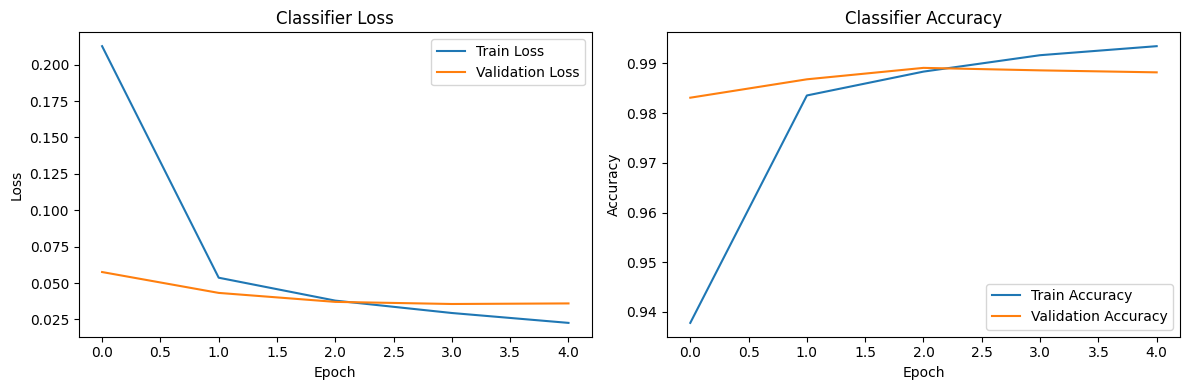

In [50]:
# ============================================================
# Cell 16: Plot classifier training history
# ============================================================

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(clf_history.history["loss"], label="Train Loss")
plt.plot(clf_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(clf_history.history["accuracy"], label="Train Accuracy")
plt.plot(clf_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# Cell 17: Evaluate classifier on clean, noisy, and denoised MNIST
# ============================================================
# This compares recognition performance across the three conditions.

clean_loss, clean_acc = classifier.evaluate(x_test, y_test, verbose=0)
noisy_loss, noisy_acc = classifier.evaluate(x_test_noisy, y_test, verbose=0)
denoised_loss, denoised_acc = classifier.evaluate(denoised_images, y_test, verbose=0)

print(f"Clean test accuracy    : {clean_acc:.4f}")
print(f"Noisy test accuracy    : {noisy_acc:.4f}")
print(f"Denoised test accuracy : {denoised_acc:.4f}")

Clean test accuracy    : 0.9882
Noisy test accuracy    : 0.4544
Denoised test accuracy : 0.9572


In [52]:
# ============================================================
# Cell 18: Generate class predictions
# ============================================================

y_pred_clean = np.argmax(classifier.predict(x_test), axis=1)
y_pred_noisy = np.argmax(classifier.predict(x_test_noisy), axis=1)
y_pred_denoised = np.argmax(classifier.predict(denoised_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 


In [53]:
# ============================================================
# Cell 19: Print classification reports
# ============================================================

print("Classification report: CLEAN MNIST")
print(classification_report(y_test, y_pred_clean))

print("\nClassification report: NOISY MNIST")
print(classification_report(y_test, y_pred_noisy))

print("\nClassification report: DENOISED MNIST")
print(classification_report(y_test, y_pred_denoised))

Classification report: CLEAN MNIST
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.96      1.00      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Classification report: NOISY MNIST
              precision    recall  f1-score   support

           0       1.00      0.09      0.16       980
           1       0.96      0.12      0.21      1135
       

In [54]:
# ============================================================
# Cell 20: Compute confusion matrices
# ============================================================

cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_noisy = confusion_matrix(y_test, y_pred_noisy)
cm_denoised = confusion_matrix(y_test, y_pred_denoised)

print("Confusion matrix: CLEAN")
print(cm_clean)

print("\nConfusion matrix: NOISY")
print(cm_noisy)

print("\nConfusion matrix: DENOISED")
print(cm_denoised)

Confusion matrix: CLEAN
[[ 968    0    0    0    0    2    6    2    2    0]
 [   0 1130    0    0    0    2    1    0    2    0]
 [   0    0 1026    0    0    0    0    6    0    0]
 [   0    0    0  998    0   12    0    0    0    0]
 [   0    1    1    0  964    0    2    2    3    9]
 [   0    0    0    2    0  889    1    0    0    0]
 [   1    1    0    1    1    8  946    0    0    0]
 [   0    0    5    1    0    1    0 1018    1    2]
 [   1    0    2    3    0    4    1    1  960    2]
 [   1    1    1    1    1   12    0    4    5  983]]

Confusion matrix: NOISY
[[ 87   0 315 153   3 296   7   0 107  12]
 [  0 133 193 405  88  84   1   0 231   0]
 [  0   0 776 209   2  19   0   0  26   0]
 [  0   0   3 961   0  44   0   0   2   0]
 [  0   1  44  71 632  68   0   0 164   2]
 [  0   0   0  54   0 831   0   0   7   0]
 [  0   3  40 155  24 465 192   0  79   0]
 [  0   1 178 562   8 149   0  79  46   5]
 [  0   0  15 170   0  61   0   0 728   0]
 [  0   0  32 403  44 218   0   0

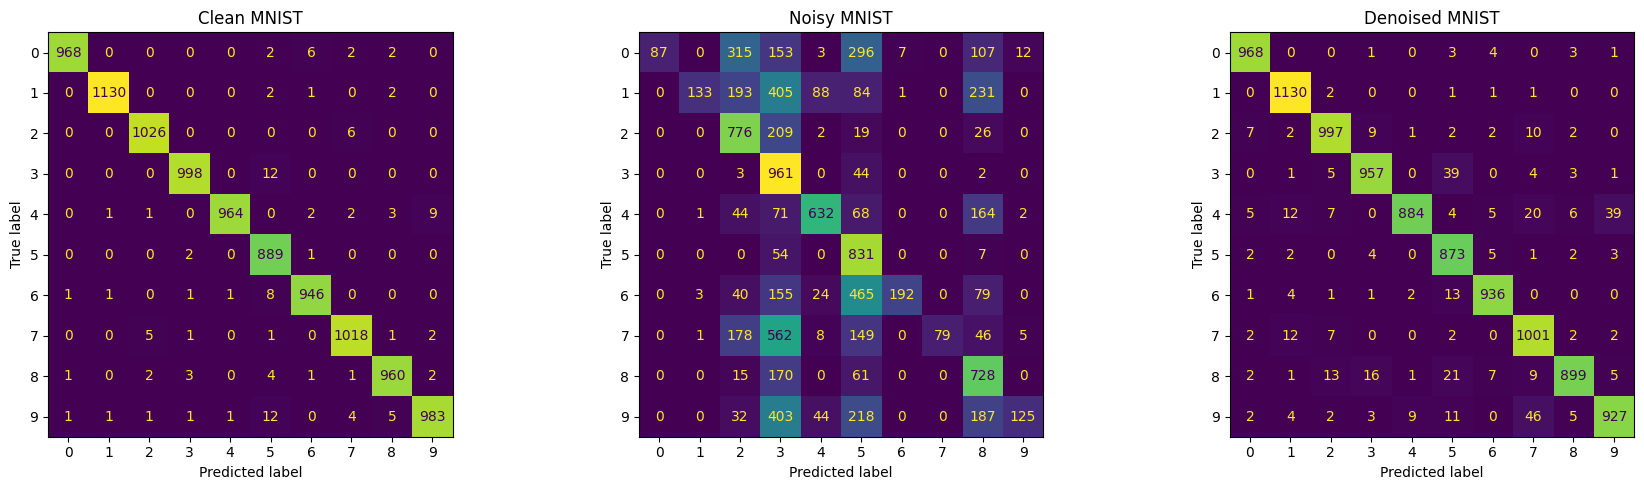

In [55]:
# ============================================================
# Cell 21: Plot confusion matrices
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Clean MNIST")

ConfusionMatrixDisplay(cm_noisy).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Noisy MNIST")

ConfusionMatrixDisplay(cm_denoised).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Denoised MNIST")

plt.tight_layout()
plt.show()

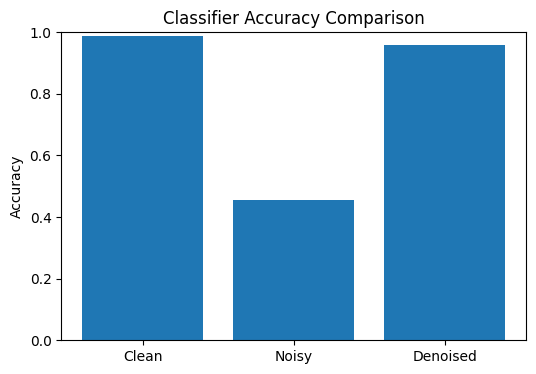

Clean: 0.9882
Noisy: 0.4544
Denoised: 0.9572


In [56]:
# ============================================================
# Cell 22: Compare classification accuracy across conditions
# ============================================================

conditions = ["Clean", "Noisy", "Denoised"]
accuracies = [clean_acc, noisy_acc, denoised_acc]

plt.figure(figsize=(6, 4))
plt.bar(conditions, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")
plt.show()

for name, acc in zip(conditions, accuracies):
    print(f"{name}: {acc:.4f}")

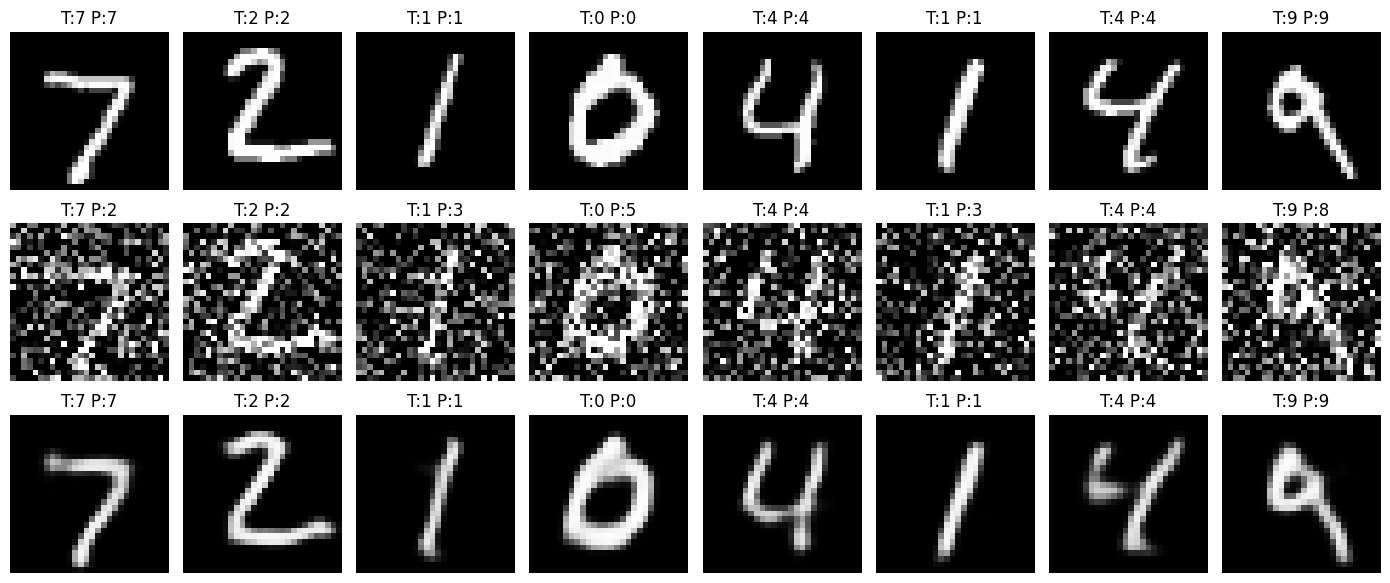

In [57]:
# ============================================================
# Cell 23: Visual comparison with predicted labels
# ============================================================

n = 8
plt.figure(figsize=(14, 6))

for i in range(n):
    # Clean
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_clean[i]}")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_noisy[i]}")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(f"T:{y_test[i]} P:{y_pred_denoised[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()